# Regime Geometry Analysis

This notebook implements a continuous "regime geometry" approach to session analysis, moving away from discrete clusters. We define sessions by their position along interpretable low-dimensional axes (Interactional Volatility, Regime Diversity, etc.) and test how these axes relate to dyadic coupling and micro-dynamics.

## 1. Setup and Data Loading

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import entropy, spearmanr, pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Style
plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.grid'] = False
plt.rcParams["svg.fonttype"] = "none"  # Editable text in SVG

# Paths
ARTIFACTS_DIR = Path("../artifacts")
CHMM_DIR = ARTIFACTS_DIR / "chmm"
RQA_DIR = ARTIFACTS_DIR / "joint_affect_catRQA"
REGIME_DIR = ARTIFACTS_DIR / "regime_geometry"
REGIME_DIR.mkdir(parents=True, exist_ok=True)

# Load Metadata & Viterbi
decoded_sessions_path = CHMM_DIR / "decoded_sessions.csv"
if not decoded_sessions_path.exists():
    raise FileNotFoundError(f"Missing {decoded_sessions_path}")

df_sessions = pd.read_csv(decoded_sessions_path)
print(f"Loaded {len(df_sessions)} sessions metadata.")

# Load Viterbi Paths
viterbi_paths = {}
for idx, row in df_sessions.iterrows():
    p = CHMM_DIR / row['path_file']
    if p.exists():
        viterbi_paths[row['session_id']] = np.load(p)

print(f"Loaded {len(viterbi_paths)} viterbi paths.")

# Load Coupling Results
coupling_path = ARTIFACTS_DIR / "coupling_results.csv" # M1 vs M0
directionality_path = ARTIFACTS_DIR / "directionality_results.csv" # Decomposition

if coupling_path.exists():
    df_coupling = pd.read_csv(coupling_path)
    print("Loaded coupling results.")
else:
    print("Warning: Coupling results not found.")
    df_coupling = None

if directionality_path.exists():
    df_directionality = pd.read_csv(directionality_path)
    print("Loaded directionality results.")
else:
    print("Warning: Directionality results not found.")
    df_directionality = None

# Load RQA Results (if available)
rqa_path = RQA_DIR / "catrqa_episode_results.csv"
if rqa_path.exists():
    df_rqa = pd.read_csv(rqa_path)
    print("Loaded RQA results.")
else:
    print("Warning: RQA results not found.")
    df_rqa = None

Loaded 123 sessions metadata.
Loaded 123 viterbi paths.
Loaded coupling results.
Loaded directionality results.
Loaded RQA results.


## 2. Feature Computation

We compute the "raw ingredients" for the axes:
* **Occupancy** (Proportion of time in each state)
* **Switching Rate** (Volatility)
* **Mean Dwell** (Stability)
* **CV Dwell** (Burstiness)
* **Transition Entropy** (Predictability)
* **Occupancy Entropy** (Regime Diversity)

In [81]:
def compute_features(session_id, path, n_states=8):
    stats = {'session_id': session_id, 'length': len(path)}

    # 1. Occupancy & Diversity
    counts = np.bincount(path, minlength=n_states)
    occ = counts / len(path)
    stats['occ_entropy'] = entropy(occ, base=2)  # Regime Diversity

    # Store raw occupancies
    for k in range(n_states):
        stats[f'occ_{k}'] = occ[k]

    # 2. Dynamics / Volatility
    if len(path) > 1:
        n_switches = np.sum(path[:-1] != path[1:])
        stats['switching_rate'] = n_switches / (len(path) - 1)
    else:
        stats['switching_rate'] = 0.0

    # 3. Dwell Stats (run-length encoding)
    loc_run_start = np.empty(len(path), dtype=bool)
    loc_run_start[0] = True
    np.not_equal(path[:-1], path[1:], out=loc_run_start[1:])
    run_starts = np.nonzero(loc_run_start)[0]
    run_lengths = np.diff(np.append(run_starts, len(path)))

    stats['mean_dwell'] = np.mean(run_lengths)
    if np.mean(run_lengths) > 0:
        stats['cv_dwell'] = np.std(run_lengths) / np.mean(run_lengths)
    else:
        stats['cv_dwell'] = 0.0

    # 4. Transition Entropy
    trans_counts = np.zeros((n_states, n_states))
    for t in range(len(path) - 1):
        trans_counts[path[t], path[t + 1]] += 1

    row_sums = trans_counts.sum(axis=1, keepdims=True)
    trans_probs = np.divide(trans_counts, row_sums, out=np.zeros_like(trans_counts), where=row_sums != 0)
    row_entropies = np.array([entropy(row, base=2) if s > 0 else 0 for row, s in zip(trans_probs, row_sums)])
    stats['trans_entropy'] = np.sum(occ * row_entropies)

    return stats


# Infer K
occ_cols = [c for c in df_sessions.columns if c.startswith('occ_')]
K = len(occ_cols) if occ_cols else 8
print(f"Using K={K}")

features = []
for sid, path in viterbi_paths.items():
    features.append(compute_features(sid, path, n_states=K))

df_features = pd.DataFrame(features)
print("Features computed.")
df_features.head()

Using K=8
Features computed.


,session_id,length,occ_entropy,occ_0,occ_1,occ_2,occ_3,occ_4,occ_5,occ_6,occ_7,switching_rate,mean_dwell,cv_dwell,trans_entropy
0,001_A,2700,2.278750,0.255556,0.267407,0.160000,0.000000,0.084444,0.001852,0.005556,0.225185,0.674324,1.482702,0.918956,1.076239
1,001_B,2700,2.542613,0.236667,0.253704,0.105556,0.000000,0.035556,0.037407,0.152593,0.178519,0.650982,1.535836,1.025301,1.190237
2,002_A,2700,2.479830,0.255185,0.269630,0.158148,0.008889,0.058889,0.014074,0.045926,0.189259,0.656910,1.521984,1.060387,1.083301
3,002_B,2700,1.985619,0.355556,0.367037,0.034074,0.000370,0.006296,0.003333,0.059259,0.174074,0.791775,1.262862,1.148329,0.665821
4,004_A,1686,2.282065,0.217082,0.240214,0.358837,0.000000,0.061091,0.025504,0.019573,0.077699,0.576261,1.734568,1.105410,1.085598


## 3. Dimensionality Reduction (Defining the Axes)

We define our axes using PCA on selected features. 
**Likely Axes:**
1.  **Interactional Volatility**: Loaded by Switching Rate, Mean Dwell (-), Transition Entropy.
2.  **Regime Diversity**: Loaded by Occupancy Entropy, CV Dwell (maybe).

We will verify this with the loadings.

Explained Variance Ratio: [0.47384503 0.32407522 0.16350679]

PCA Loadings:


,PC1,PC2,PC3
switching_rate,0.618053,0.200807,0.136823
mean_dwell,-0.502274,-0.369718,-0.447329
cv_dwell,-0.293224,-0.405770,0.793762
trans_entropy,-0.392082,0.578696,-0.134972
occ_entropy,-0.354996,0.568724,0.364556


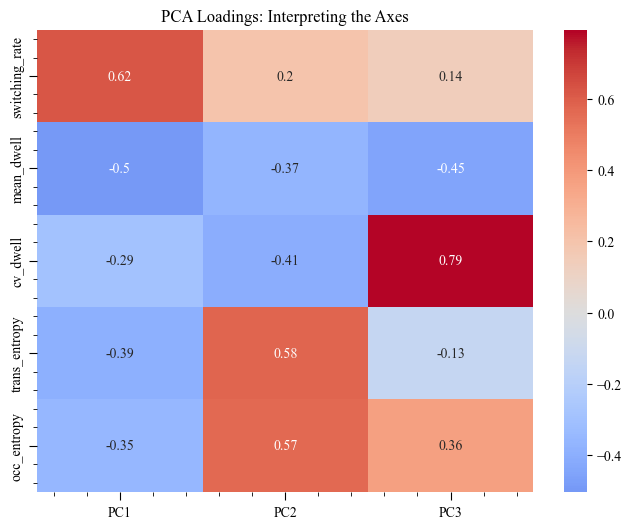

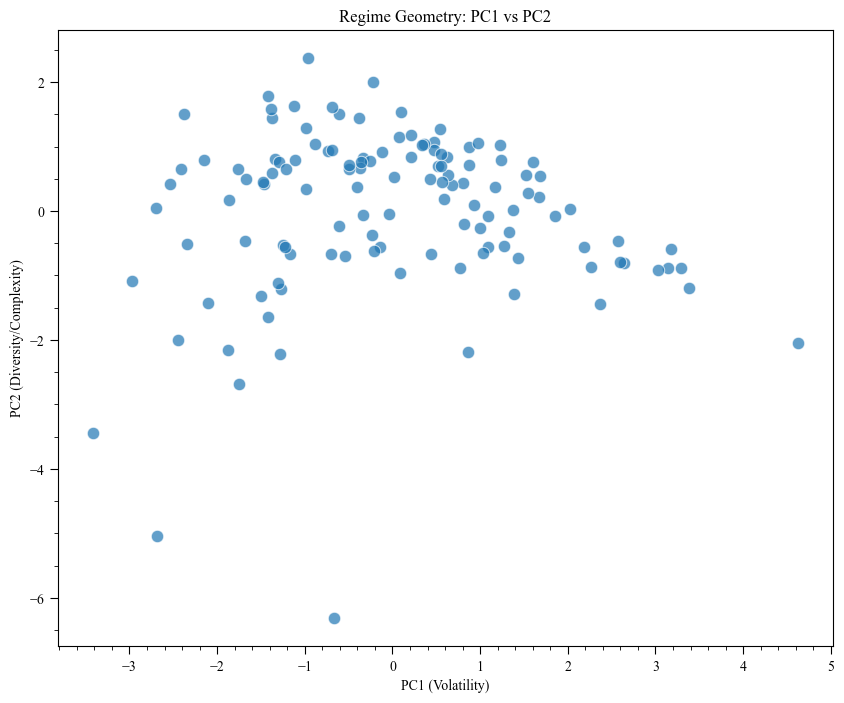

In [82]:
# Select features for PCA
# We focus on the "Form" of the session, not the specific content (e.g. which specific state is active),
# although Occupancy Entropy captures the shape of content.
pca_cols = ['switching_rate', 'mean_dwell', 'cv_dwell', 'trans_entropy', 'occ_entropy']

X = df_features[pca_cols].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Store results
df_features['PC1'] = X_pca[:, 0]
df_features['PC2'] = X_pca[:, 1]
df_features['PC3'] = X_pca[:, 2]

# --- Interpret Loadings ---
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2', 'PC3'], 
    index=pca_cols
)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("\nPCA Loadings:")
display(loadings)

# Plot Loadings Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(loadings, annot=True, cmap="coolwarm", center=0)
plt.title("PCA Loadings: Interpreting the Axes")
ax = plt.gca()
ax.tick_params(axis='both', which='major', direction='out', length=6)
ax.tick_params(axis='both', which='minor', direction='out', length=3)
ax.minorticks_on()
fig = plt.gcf()
fig.savefig(REGIME_DIR / "pca_loadings_heatmap.svg", format="svg")
plt.show()

# Visualize the Geometry (PC1 vs PC2)
plt.figure(figsize=(10, 8))
ax = sns.scatterplot(x='PC1', y='PC2', data=df_features, alpha=0.7, s=80, palette='viridis')
plt.title("Regime Geometry: PC1 vs PC2")
plt.xlabel("PC1 (Volatility)")
plt.ylabel("PC2 (Diversity/Complexity)")
# Style ticks
ax = plt.gca()
ax.tick_params(axis='both', which='major', direction='out', length=6)
ax.tick_params(axis='both', which='minor', direction='out', length=3)
ax.minorticks_on()
fig = plt.gcf()
fig.savefig(REGIME_DIR / "pc1_vs_pc2_scatter.svg", format="svg")
plt.show()

## 4. Visualization with UMAP
We use UMAP for visualization, coloring by our interpretable PC axes.

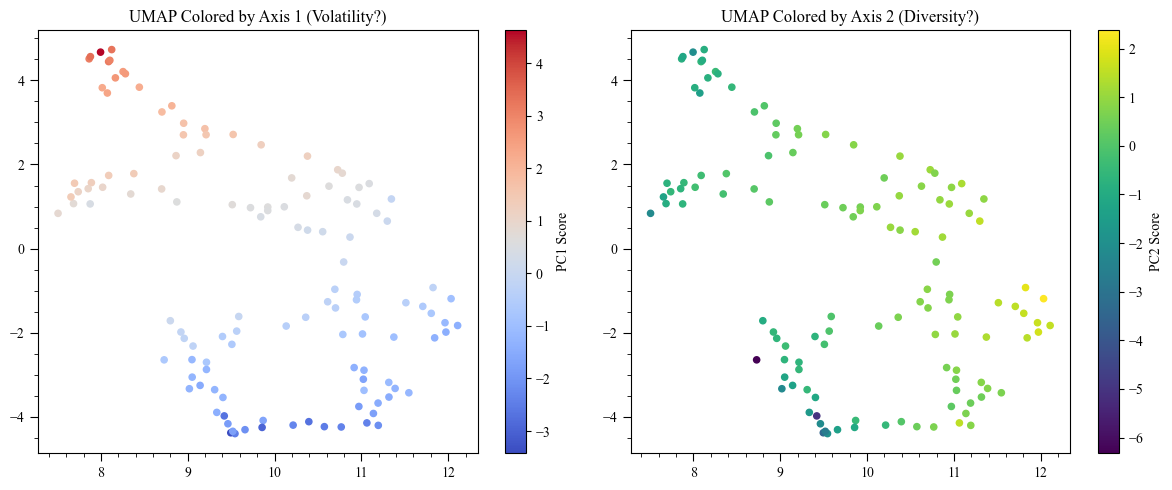

In [83]:
reducer = umap.UMAP(random_state=42, n_neighbors=15, min_dist=0.1)
embedding = reducer.fit_transform(X_scaled)

fig = plt.figure(figsize=(12, 5))

# Color by PC1
plt.subplot(1, 2, 1)
sc = plt.scatter(embedding[:, 0], embedding[:, 1], c=df_features['PC1'], cmap='coolwarm', s=20)
plt.colorbar(sc, label='PC1 Score')
plt.title("UMAP Colored by Axis 1 (Volatility?)")
ax = plt.gca()
ax.tick_params(axis='both', which='major', direction='out', length=6)
ax.tick_params(axis='both', which='minor', direction='out', length=3)
ax.minorticks_on()

# Color by PC2
plt.subplot(1, 2, 2)
sc = plt.scatter(embedding[:, 0], embedding[:, 1], c=df_features['PC2'], cmap='viridis', s=20)
plt.colorbar(sc, label='PC2 Score')
plt.title("UMAP Colored by Axis 2 (Diversity?)")
ax = plt.gca()
ax.tick_params(axis='both', which='major', direction='out', length=6)
ax.tick_params(axis='both', which='minor', direction='out', length=3)
ax.minorticks_on()

plt.tight_layout()
fig = plt.gcf()
fig.savefig(REGIME_DIR / "umap_pc1_pc2.svg", format="svg")
plt.show()

## 5. Testing the Axes
### 5.1 Coupling vs Regime Geometry
Do volatility (PC1) or diversity (PC2) predict stronger coupling?
We correlate PC scores with:
* $\Delta C$ (Client Gain)
* $\Delta T$ (Therapist Gain)
* Asymmetry ($\Delta C - \Delta T$)

In [84]:
if df_coupling is not None and df_directionality is not None:
    print("Coupling DF cols:", df_coupling.columns)

    # Ensure dyad_id is available on session-level feature table
    if 'dyad_id' not in df_features.columns:
        df_features = df_features.merge(df_sessions[['session_id', 'dyad_id']], on='session_id', how='left')

    # Length-weighted aggregation to dyad level
    def wavg(x, w):
        s = w.sum()
        return np.nan if s == 0 else np.sum(x * w) / s

    dyad_geometry = (
        df_features
        .groupby('dyad_id', as_index=False)
        .apply(lambda g: pd.Series({
            'PC1': wavg(g['PC1'].to_numpy(), g['length'].to_numpy()),
            'PC2': wavg(g['PC2'].to_numpy(), g['length'].to_numpy()),
            'switching_rate': wavg(g['switching_rate'].to_numpy(), g['length'].to_numpy()),
            'n_sessions': len(g),
            'total_length': g['length'].sum(),
        }))
        .reset_index(drop=True)
    )

    # Merge with coupling/directionality
    df_merged = dyad_geometry.merge(df_coupling, on='dyad_id', suffixes=('_geom', '_cpl'))
    df_merged = df_merged.merge(df_directionality, on='dyad_id', suffixes=('', '_dir'))

    print("Merged Columns:", df_merged.columns)

    target_cols = [c for c in df_coupling.columns if c not in ['dyad_id', 'fold']]

    print("\n--- Correlations with PC1 (Volatility) ---")
    for tc in target_cols:
        if tc in df_merged.columns:
            r, p = spearmanr(df_merged['PC1'], df_merged[tc])
            print(f"{tc}: r={r:.3f}, p={p:.4f}")

    print("\n--- Correlations with PC2 (Diversity) ---")
    for tc in target_cols:
        if tc in df_merged.columns:
            r, p = spearmanr(df_merged['PC2'], df_merged[tc])
            print(f"{tc}: r={r:.3f}, p={p:.4f}")
else:
    print("Skipping Coupling analysis (data missing).")

Coupling DF cols: Index(['fold', 'session_id', 'dyad_id', 'n_transitions', 'll0_total',
       'll1_total', 'll0_per_trans', 'll1_per_trans', 'gain_per_trans'],
      dtype='object')
Merged Columns: Index(['dyad_id', 'PC1', 'PC2', 'switching_rate', 'n_sessions', 'total_length',
       'fold', 'session_id', 'n_transitions', 'll0_total', 'll1_total',
       'll0_per_trans', 'll1_per_trans', 'gain_per_trans', 'fold_dir',
       'session_id_dir', 'nT', 'nC', 'dT_per_trans', 'dC_per_trans',
       'dT_total', 'dC_total'],
      dtype='object')

--- Correlations with PC1 (Volatility) ---
session_id: r=-0.275, p=0.0002
n_transitions: r=0.085, p=0.2533
ll0_total: r=0.287, p=0.0001
ll1_total: r=0.285, p=0.0001
ll0_per_trans: r=0.413, p=0.0000
ll1_per_trans: r=0.407, p=0.0000
gain_per_trans: r=0.124, p=0.0951

--- Correlations with PC2 (Diversity) ---
session_id: r=-0.023, p=0.7543
n_transitions: r=0.092, p=0.2159
ll0_total: r=-0.449, p=0.0000
ll1_total: r=-0.447, p=0.0000
ll0_per_trans: r=-0.38

### 5.2 Dyadic Recurrence
Does position in PC-space predict recurrence?
We compute the Euclidean distance in (PC1, PC2) space for every pair of sessions belonging to the same dyad.
Then we compare this distance distribution to random pairs.
Or: Do dyads with "close" sessions have different coupling characteristics?

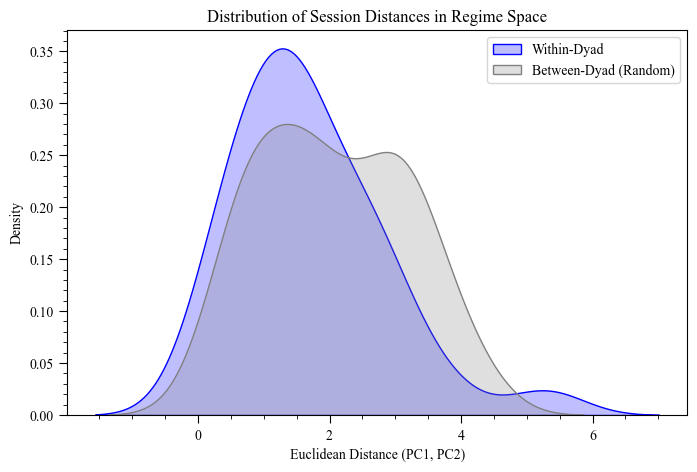

Repeated-session dyads (>=2 sessions): 30
Median within-dyad distance: 1.4717
Median random distance: 1.8593
Mann-Whitney U: 348.00
p-value: 6.6727e-02
Rank-biserial effect size: 0.2267


In [85]:
# 1. Intra-dyad distances
dyad_distances = []
random_distances = []

grouped = df_features.groupby('dyad_id')
all_pcs = df_features[['PC1', 'PC2']].values

# How many dyads have repeated sessions (>=2 sessions)?
dyad_session_counts = grouped.size()
n_repeated_dyads = int((dyad_session_counts >= 2).sum())

for dyad_id, group in grouped:
    if len(group) < 2:
        continue

    # Get PC coordinates
    coords = group[['PC1', 'PC2']].values

    # Pairwise distances within dyad
    from scipy.spatial.distance import pdist
    dists = pdist(coords, metric='euclidean')
    dyad_distances.extend(dists)

# 2. Random background distances
n_random = len(dyad_distances)
idx1 = np.random.choice(len(df_features), n_random * 2)
p1 = all_pcs[idx1[:n_random]]
p2 = all_pcs[idx1[n_random:]]
rand_dists = np.linalg.norm(p1 - p2, axis=1)

# Plot
plt.figure(figsize=(8, 5))
sns.kdeplot(dyad_distances, label='Within-Dyad', fill=True, color='blue')
sns.kdeplot(rand_dists, label='Between-Dyad (Random)', fill=True, color='gray')
plt.title("Distribution of Session Distances in Regime Space")
plt.xlabel("Euclidean Distance (PC1, PC2)")
# Style ticks explicitly
ax = plt.gca()
ax.tick_params(axis='both', which='major', direction='out', length=6)
ax.tick_params(axis='both', which='minor', direction='out', length=3)
ax.minorticks_on()
plt.legend()
plt.savefig(REGIME_DIR / "dyad_distance_distribution.svg", format="svg")
plt.show()

# 3. Statistical test + effect size
from scipy.stats import mannwhitneyu

if len(dyad_distances) > 0 and len(rand_dists) > 0:
    u, p = mannwhitneyu(dyad_distances, rand_dists, alternative='less')

    median_within = float(np.median(dyad_distances))
    median_random = float(np.median(rand_dists))

    # Rank-biserial correlation (signed so positive = within-dyad distances are smaller)
    n1 = len(dyad_distances)
    n2 = len(rand_dists)
    rank_biserial = 1 - (2 * u) / (n1 * n2)

    print(f"Repeated-session dyads (>=2 sessions): {n_repeated_dyads}")
    print(f"Median within-dyad distance: {median_within:.4f}")
    print(f"Median random distance: {median_random:.4f}")
    print(f"Mann-Whitney U: {u:.2f}")
    print(f"p-value: {p:.4e}")
    print(f"Rank-biserial effect size: {rank_biserial:.4f}")
else:
    print("Insufficient distances to run dyad recurrence statistics.")

### 5.3 RQA Metrics vs Regime Geometry
Do more volatile or diverse sessions show different recurrence characteristics (Determinism, Laminarity)?
We correlate PC axes with RQA metrics.

RQA Merged shape (session-level): (123, 25)

--- Correlations with PC1 (Volatility) ---
RR: r=-0.232, p=0.0099
DET: r=-0.253, p=0.0047
LAM: r=-0.251, p=0.0051
RR_Z: r=0.045, p=0.6181
DET_Z: r=0.087, p=0.3374
LAM_Z: r=0.066, p=0.4712

--- Correlations with PC2 (Diversity) ---
RR: r=-0.337, p=0.0001
DET: r=-0.415, p=0.0000
LAM: r=-0.396, p=0.0000
RR_Z: r=-0.082, p=0.3647
DET_Z: r=-0.031, p=0.7359
LAM_Z: r=0.009, p=0.9191


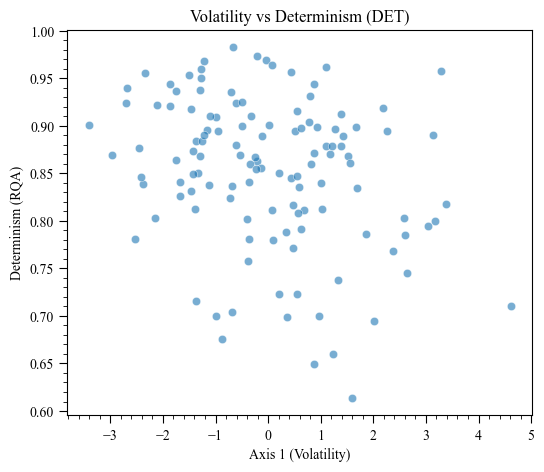

In [86]:
if df_rqa is not None:
    # catRQA file is EPISODE-level; aggregate to SESSION-level before merging
    # and map saved column names to concise metric names.
    rename_map = {
        'RR_shuffle': 'RR',
        'DET_shuffle': 'DET',
        'LAM_shuffle': 'LAM',
        'RR_Z_shuffle': 'RR_Z',
        'DET_Z_shuffle': 'DET_Z',
        'LAM_Z_shuffle': 'LAM_Z',
    }
    df_rqa_clean = df_rqa.rename(columns=rename_map).copy()

    metric_cols = [c for c in ['RR', 'DET', 'LAM', 'RR_Z', 'DET_Z', 'LAM_Z'] if c in df_rqa_clean.columns]

    if 'duration' in df_rqa_clean.columns:
        # Duration-weighted session aggregation
        df_rqa_session = (
            df_rqa_clean
            .groupby('session_id', as_index=False)
            .apply(lambda g: pd.Series({
                m: np.average(g[m], weights=g['duration']) if g['duration'].sum() > 0 else np.nan
                for m in metric_cols
            }))
            .reset_index(drop=True)
        )
    else:
        # Fallback: unweighted mean
        df_rqa_session = df_rqa_clean.groupby('session_id', as_index=False)[metric_cols].mean()

    df_rqa_merged = df_features.merge(df_rqa_session, on='session_id', how='inner')
    print(f"RQA Merged shape (session-level): {df_rqa_merged.shape}")

    print("\n--- Correlations with PC1 (Volatility) ---")
    for rc in metric_cols:
        r, p = spearmanr(df_rqa_merged['PC1'], df_rqa_merged[rc], nan_policy='omit')
        print(f"{rc}: r={r:.3f}, p={p:.4f}")

    print("\n--- Correlations with PC2 (Diversity) ---")
    for rc in metric_cols:
        r, p = spearmanr(df_rqa_merged['PC2'], df_rqa_merged[rc], nan_policy='omit')
        print(f"{rc}: r={r:.3f}, p={p:.4f}")

    if 'DET' in df_rqa_merged.columns:
        plt.figure(figsize=(6, 5))
        sns.scatterplot(x='PC1', y='DET', data=df_rqa_merged, alpha=0.6)
        plt.title("Volatility vs Determinism (DET)")
        plt.xlabel("Axis 1 (Volatility)")
        plt.ylabel("Determinism (RQA)")
        ax = plt.gca()
        ax.tick_params(axis='both', which='major', direction='out', length=6)
        ax.tick_params(axis='both', which='minor', direction='out', length=3)
        ax.minorticks_on()
        plt.savefig(REGIME_DIR / "volatility_vs_det.svg", format="svg")
        plt.show()
else:
    print("Skipping RQA analysis (data missing).")